<a href="https://colab.research.google.com/github/javier-jaime/Tool-Crib/blob/master/Colab/Introduction_to_Gradio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Introduction to Gradio**

Gradio is the way to demonstrate your machine learning model with a user-friendly web interface so that everyone can use it anywhere. Gradio is an open-source Python package that allows you to quickly build a demo or web application for your machine learning model, API, or any arbitrary Python function. You can then share a link to your demo or web application using Gradio's built-in sharing features. No JavaScript, CSS, or web hosting experience is needed.

### Why Use Gradio?

Gradio is useful for several reasons:

Ease of use: Gradio enables the creation of interfaces for models with just a few lines of code.
Flexibility: Gradio supports various inputs and outputs, such as text, images, files, and more.
Sharing and collaboration: Interfaces can be shared with others through unique URLs, facilitating easy collaboration and feedback collection.

### Task 1: Getting Started with Gradio

To begin using Gradio, you first need to install the library. You can install Gradio using pip

In [3]:
!pip install gradio

###Creating Your First Gradio Interface
You can run Gradio in your favorite code editor, Jupyter notebook, Google Colab, or anywhere else you write Python. Let's write your first Gradio app

In [4]:
import gradio as gr
def greet(name, intensity):
  return "Hello, " + name + "!" * int(intensity)
demo = gr.Interface(
  fn=greet,
  inputs=["text", "slider"],
  outputs=["text"],
)
demo.launch(server_name="127.0.0.1", server_port= 7860)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60170fecfef6cd8e9b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


If running from a file, the demo below will open in a browser on http://127.0.0.1:7860. If you are running within a notebook, the demo will appear embedded within the notebook.

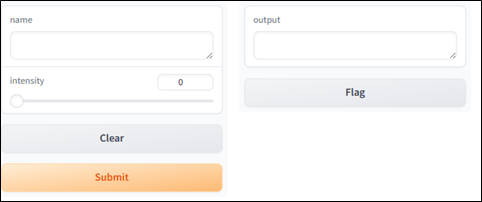

Type your name in the textbox on the left, drag the slider, and then press the Submit button. You should see a friendly greeting on the right.

###Understanding the Interface class

Note that to make your first demo, you created an instance of the **`gr.Interface`** class. The Interface class is designed to create demos for machine learning models that accept one or more inputs and return one or more outputs.


The Interface class has three core arguments:

**fn:** The function to wrap a user interface (UI) around

**inputs:** The Gradio component(s) to use for the input. The number of components should match the number of arguments in your function.

**outputs:** The Gradio component(s) to use for the output. The number of components should match the number of return values from your function.

The **fn** argument is flexible — you can pass any Python function you want to wrap with a UI. In the example above, you saw a relatively simple function, but the function could be anything from a music generator to a tax calculator to the prediction function of a pretrained machine learning model.

The **input** and **output** arguments take one or more Gradio components. As we'll see, Gradio includes more than 30 built-in components (such as the **`gr.Textbox()`**, **`gr.Image()`**, and **`gr.HTML()`** components) that are designed for machine learning applications.

If your function accepts more than one argument, as is the case above, pass a list of input components to inputs, with each input component corresponding to one of the function's arguments in order. The same applies if your function returns more than one value: simply pass a list of components to outputs. This flexibility makes the Interface class a very powerful way to create demos.

Let's create a simple interface for an image captioning model. The BLIP (Bootstrapped Language Image Pretraining) model can generate captions for images. Here's how you can create a Gradio interface for the BLIP model.

In [5]:
!pip install transformers
!pip install torch

In [6]:
import gradio as gr
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
def generate_caption(image):
    # Now directly using the PIL Image object
    inputs = processor(images=image, return_tensors="pt")
    outputs = model.generate(**inputs)
    caption = processor.decode(outputs[0], skip_special_tokens=True)
    return caption
def caption_image(image):
    """
    Takes a PIL Image input and returns a caption.
    """
    try:
        caption = generate_caption(image)
        return caption
    except Exception as e:
        return f"An error occurred: {str(e)}"
iface = gr.Interface(
    fn=caption_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Image Captioning with BLIP",
    description="Upload an image to generate a caption."
)
iface.launch(server_name="127.0.0.1", server_port= 7860)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

OSError: Cannot find empty port in range: 7860-7860. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.

Here, we use the **`BlipProcessor`** and **`BlipForConditionalGeneration`** from the **`transformers`** library to set up an image captioning model. This example demonstrates creating a web interface using Gradio, where the input parameter specifies an image and the output is the generated text caption. The title and description parameters enhance the interface by providing context and instructions for users.